<a href="https://colab.research.google.com/github/nicosepu07/desafiooo2/blob/main/desafio_telcom_parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Cargar el archivo CSV

In [3]:
import pandas as pd

df = pd.read_csv("/content/datos_tratados.csv")

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   objec

In [5]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**Eliminar columnas irrelevantes**

In [6]:
df = df.drop(columns=["customerID"])

In [7]:
df.columns

Index(['Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

**Convertir variables categóricas a numéricas**

In [8]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [9]:
df_encoded.head()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,customer.gender_Male,customer.Partner_Yes,customer.Dependents_Yes,phone.PhoneService_Yes,phone.MultipleLines_No phone service,...,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaperlessBilling_Yes,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [10]:
df_encoded.shape

(7043, 31)

**Verificar proporción de Churn**

In [11]:
df_encoded["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [12]:
df_encoded["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.73463
1,0.26537


In [13]:
df_encoded["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


**Normalización / Estandarización**

In [14]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [15]:
X.shape

(7043, 30)

In [16]:
y.shape

(7043,)

**Análisis de Correlación**

In [17]:
corr = df_encoded.corr()

In [18]:
corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
account.Charges.Monthly,0.193356
account.PaperlessBilling_Yes,0.191825
customer.SeniorCitizen,0.150889
internet.StreamingTV_Yes,0.063228
internet.StreamingMovies_Yes,0.061382
phone.MultipleLines_Yes,0.040102
phone.PhoneService_Yes,0.011942


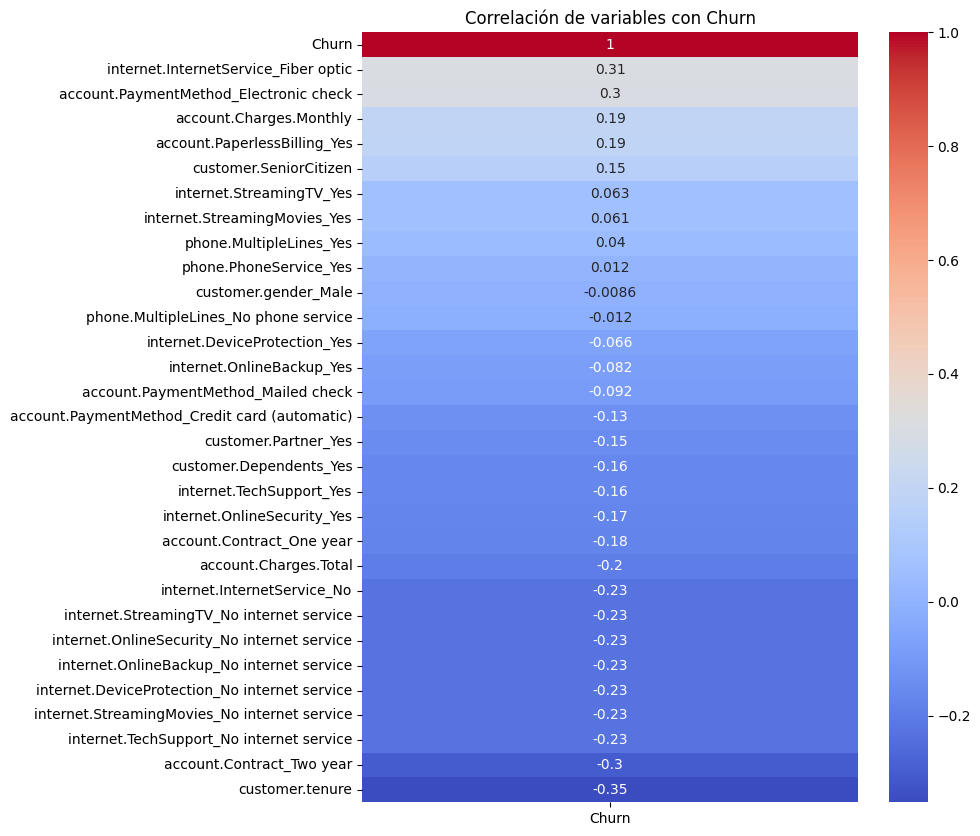

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,10))
sns.heatmap(df_encoded.corr()[["Churn"]].sort_values(by="Churn", ascending=False),
            annot=True,
            cmap="coolwarm")

plt.title("Correlación de variables con Churn")
plt.show()

In [20]:
corr["Churn"].sort_values(ascending=False)

,Churn
Churn,1.000000
internet.InternetService_Fiber optic,0.308020
account.PaymentMethod_Electronic check,0.301919
account.Charges.Monthly,0.193356
account.PaperlessBilling_Yes,0.191825
customer.SeniorCitizen,0.150889
internet.StreamingTV_Yes,0.063228
internet.StreamingMovies_Yes,0.061382
phone.MultipleLines_Yes,0.040102
phone.PhoneService_Yes,0.011942


* Análisis de correlación con Churn
Variables con mayor correlación positiva (más probabilidad de cancelar)
Variable	Correlación	Interpretación
internet.InternetService_Fiber optic	0.308	clientes con fibra cancelan más
account.PaymentMethod_Electronic check	0.302	quienes pagan con cheque electrónico cancelan más
account.Charges.Monthly	0.193	mientras más caro el plan mensual, mayor churn
account.PaperlessBilling_Yes	0.191	usuarios con facturación digital cancelan más
customer.SeniorCitizen	0.150	adultos mayores cancelan ligeramente más

* Insight de negocio:
Clientes con fibra + pagos electrónicos + cuentas mensuales altas tienen mayor riesgo de churn.

* Variables con mayor correlación negativa (menos probabilidad de cancelar)
Variable	Correlación	Interpretación
customer.tenure	-0.352	mientras más tiempo llevan, menos cancelan
account.Contract_Two year	-0.302	contratos largos reducen churn
internet.InternetService_No	-0.227	clientes sin internet cancelan menos
account.Charges.Total	-0.199	clientes que han pagado más históricamente se quedan
account.Contract_One year	-0.177	contratos de 1 año también reducen churn

* Insight de negocio:
Los clientes con contratos largos y mayor antigüedad son mucho más estables.

**Análisis dirigido**

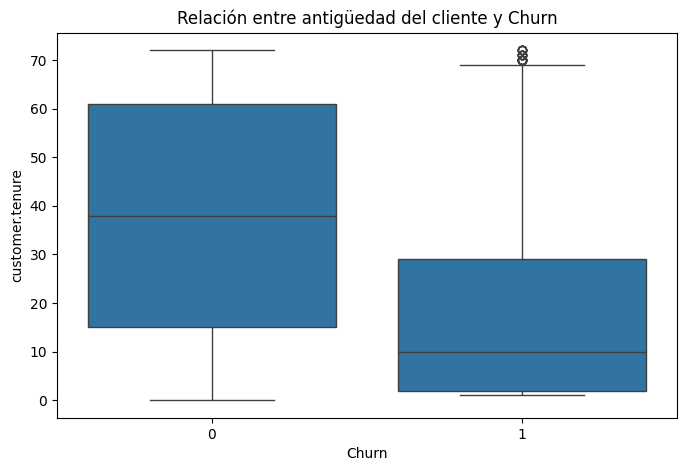

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="customer.tenure", data=df_encoded)

plt.title("Relación entre antigüedad del cliente y Churn")
plt.show()

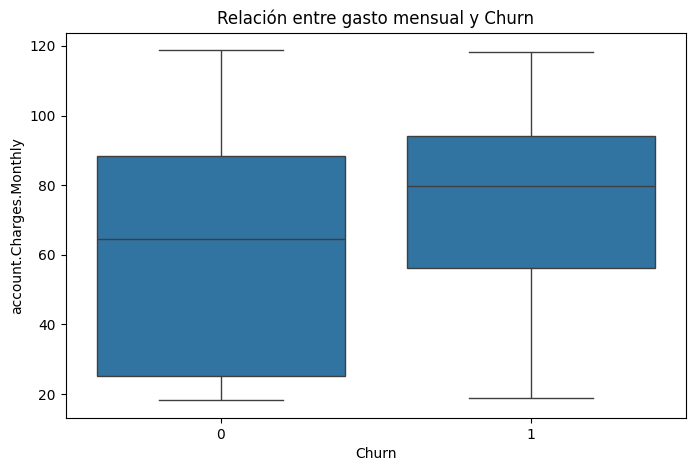

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df_encoded)

plt.title("Relación entre gasto mensual y Churn")
plt.show()

Interpretación del análisis dirigido

1️ Antigüedad del cliente vs Churn (tenure)

Lo que muestra el gráfico:

Clientes que NO cancelan (Churn = 0) tienen generalmente muchos más meses en la empresa.

Clientes que cancelan (Churn = 1) tienen muy poca antigüedad.

* Interpretación clara:

La mayoría de cancelaciones ocurre durante los primeros meses del servicio.

Después de cierto tiempo, el cliente se vuelve más estable.

 * Insight de negocio:
Telecom X debería enfocar estrategias de retención en los primeros meses del cliente.

 Ejemplos:

descuentos iniciales

soporte prioritario

beneficios por permanencia.

2️ Gasto mensual vs Churn (Monthly Charges)

El gráfico muestra que:

Los clientes que cancelan tienden a tener cargos mensuales más altos.

Los clientes que se quedan tienen en promedio planes más baratos.

* Interpretación:

Los planes caros tienen mayor churn.

* Insight de negocio:

Telecom X debería revisar:

precios de planes premium

valor percibido del servicio

beneficios adicionales para clientes con planes caros

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
X_train.shape

(5634, 30)

In [25]:
X_test.shape

(1409, 30)

In [26]:
y_train.shape

(5634,)

In [27]:
y_test.shape

(1409,)

**Crear los modelos**

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [30]:
y_pred_log = log_model.predict(X_test_scaled)

In [31]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8062455642299503

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.67      0.54      0.59       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


Confusion Matrix:

[[936 100]
 [173 200]]


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf_model.predict(X_test)

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.794180269694819

Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:

[[947  89]
 [201 172]]


**Evaluación y comparación de modelos**

| Métrica         | Regresión Logística | Random Forest |
| --------------- | ------------------- | ------------- |
| Accuracy        | **0.806**           | 0.794         |
| Precision churn | **0.67**            | 0.66          |
| Recall churn    | **0.54**            | 0.46          |
| F1-score churn  | **0.59**            | 0.54          |


**Importancia de variables**

In [35]:
import pandas as pd

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "variable": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)

,variable,importance
3,account.Charges.Total,0.194742
2,account.Charges.Monthly,0.168468
1,customer.tenure,0.166064
28,account.PaymentMethod_Electronic check,0.042890
10,internet.InternetService_Fiber optic,0.035186
25,account.Contract_Two year,0.033004
4,customer.gender_Male,0.027205
26,account.PaperlessBilling_Yes,0.026222
13,internet.OnlineSecurity_Yes,0.026045
19,internet.TechSupport_Yes,0.023885


**Importancia de variables**

Las variables más importantes que encontró Random Forest fueron:

| Variable                       | Importancia | Interpretación                        |
| ------------------------------ | ----------- | ------------------------------------- |
| account.Charges.Total          | **0.194**   | dinero total que ha pagado el cliente |
| account.Charges.Monthly        | **0.168**   | costo mensual del servicio            |
| customer.tenure                | **0.166**   | antigüedad del cliente                |
| PaymentMethod_Electronic check | **0.042**   | método de pago                        |
| InternetService_Fiber optic    | **0.035**   | tipo de internet                      |
| Contract_Two year              | **0.033**   | duración del contrato                 |
| gender_Male                    | 0.027       | impacto menor                         |
| PaperlessBilling               | 0.026       | facturación digital                   |
| OnlineSecurity                 | 0.026       | servicio adicional                    |
| TechSupport                    | 0.023       | soporte técnico                       |



Interpretación de negocio

1️ Antigüedad del cliente (Tenure)

Es uno de los factores más importantes.

- Insight:

Clientes nuevos tienen mayor probabilidad de cancelar.

Clientes con más tiempo son mucho más estables.

- Estrategia:

programas de fidelización temprana

beneficios en los primeros meses.

2️ Cargos mensuales

Los clientes con planes más caros cancelan más.

- Posibles causas:

percepción de precio alto

valor percibido insuficiente.

Estrategia:

agregar beneficios a planes premium

revisar estructura de precios.

3️ Cargos totales

Clientes que han gastado más dinero acumulado tienden a quedarse.

- Esto indica lealtad del cliente.

4️ Tipo de contrato

Contratos largos reducen significativamente el churn.

Especialmente:

contratos de 2 años.

- Estrategia:

incentivos para contratos largos.

5️ Tipo de internet

Clientes con Fiber optic cancelan más.

Esto puede indicar:

problemas de servicio

expectativas más altas.

**Conclusión estratégica**

A partir del análisis exploratorio y el desarrollo de modelos predictivos, se identificaron los principales factores asociados a la cancelación de clientes en Telecom X.

Los modelos de machine learning mostraron un desempeño cercano al 80% de exactitud, siendo la Regresión Logística el modelo con mejor capacidad para detectar clientes en riesgo de cancelación.

Entre las variables más relevantes para predecir el churn destacan la antigüedad del cliente, los cargos mensuales, el gasto total acumulado, el tipo de contrato y el método de pago.

Los resultados indican que los clientes con menor antigüedad, con cargos mensuales más altos y con contratos de corto plazo presentan mayor probabilidad de cancelar el servicio.

En base a estos hallazgos, se recomienda implementar estrategias de retención enfocadas en los primeros meses de relación con el cliente, ofrecer incentivos para contratos de mayor duración y revisar la propuesta de valor de los planes de mayor costo.